# Assignment 03: Deep Learning Project - Customer Churn Prediction


**Muhammad Asjid Butt**

## Data Loading & Exploration
In this section, we import libraries, load the Telco Customer Churn dataset, check its properties, handle the specific issue with `TotalCharges`, and visualize the class balance.

In [4]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
df = pd.read_csv('Telco Customer Churn Dataset.csv')

# Dataset overview
print(f"Dataset Shape: {df.shape}")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-


Missing values per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


/tmp/ipykernel_2825/134446728.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


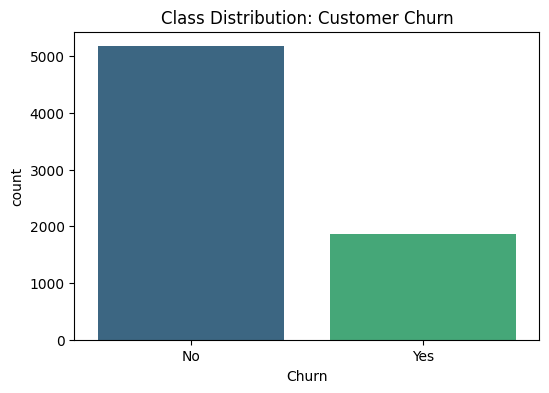

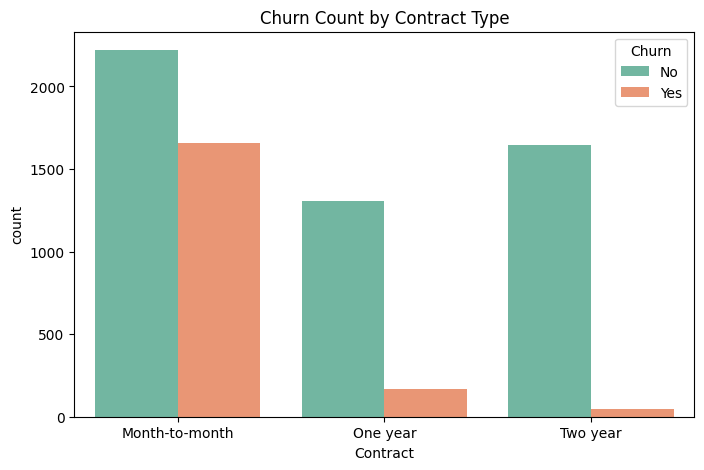

In [5]:
# Handle 'TotalCharges' which is read as an object/string due to blank spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Missing value analysis
print("\nMissing values per column:")
print(df.isnull().sum())

# Class distribution (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Class Distribution: Customer Churn')
plt.show()

# Data visualization: Churn vs Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn Count by Contract Type')
plt.show()

## Data Preprocessing
Here we will drop rows with missing values, drop the irrelevant `customerID` column, encode categorical variables, and scale our numerical features for the neural network.

**Encoding Justification:** We use Label Encoding for binary features (like `Gender`, `Partner`, `Churn`) because they only have two states (0 or 1), keeping the feature space compact. We use One-Hot Encoding for multi-class features (like `Contract`, `PaymentMethod`) to prevent the model from falsely assuming an ordinal mathematical relationship between categories.

In [6]:
# Handle missing values by dropping them
df.dropna(inplace=True)

# Drop irrelevant customerID
df.drop('customerID', axis=1, inplace=True)

# Separate target and features
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify column types
binary_cols = [col for col in X.columns if X[col].nunique() == 2]
multi_cols = [col for col in X.columns if X[col].nunique() > 2 and X[col].dtype == 'object']
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Encode categorical features
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (5625, 30)
Testing features shape: (1407, 30)


## Build Neural Networks
We will construct two models: a standard Dense baseline and a tuned version implementing Dropout and Batch Normalization to prevent overfitting.

In [7]:
input_dim = X_train_scaled.shape[1]

# Model 1: Baseline Dense Neural Network
baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2: Improved Dense Neural Network (Dropout + Batch Normalization)
tuned_model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

tuned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping callback for the tuned model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Baseline Model...
Training Tuned Model...


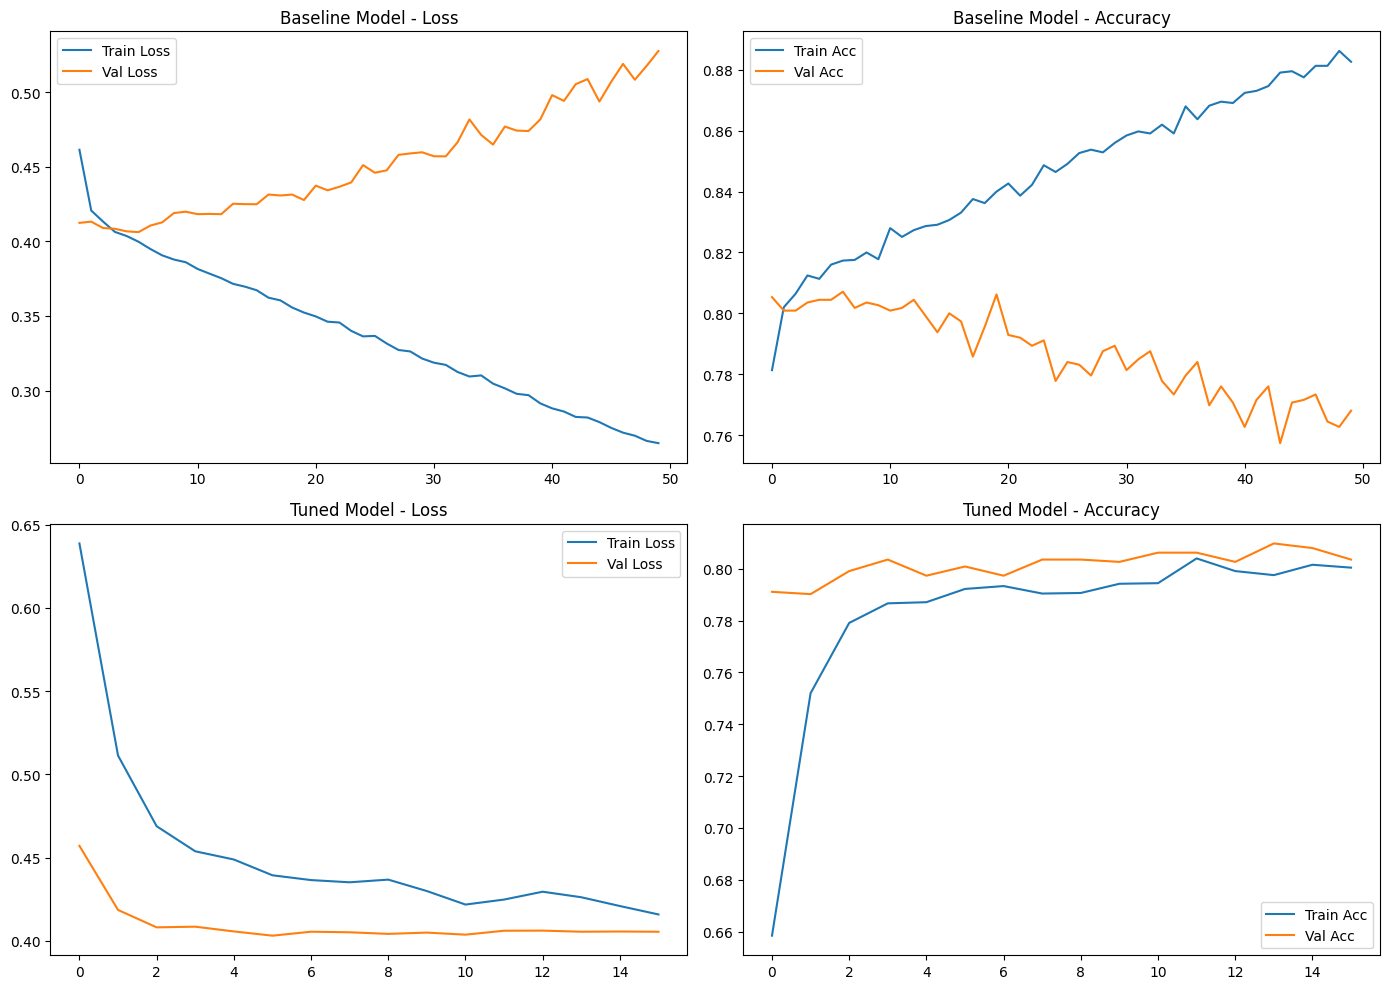

In [8]:
epochs_count = 50

# Train Baseline
print("Training Baseline Model...")
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=epochs_count,
    batch_size=32,
    verbose=0
)

# Train Tuned Model
print("Training Tuned Model...")
tuned_history = tuned_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=epochs_count,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Plot training/validation accuracy and loss
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline Loss
axes[0, 0].plot(baseline_history.history['loss'], label='Train Loss')
axes[0, 0].plot(baseline_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Baseline Model - Loss')
axes[0, 0].legend()

# Baseline Accuracy
axes[0, 1].plot(baseline_history.history['accuracy'], label='Train Acc')
axes[0, 1].plot(baseline_history.history['val_accuracy'], label='Val Acc')
axes[0, 1].set_title('Baseline Model - Accuracy')
axes[0, 1].legend()

# Tuned Loss
axes[1, 0].plot(tuned_history.history['loss'], label='Train Loss')
axes[1, 0].plot(tuned_history.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('Tuned Model - Loss')
axes[1, 0].legend()

# Tuned Accuracy
axes[1, 1].plot(tuned_history.history['accuracy'], label='Train Acc')
axes[1, 1].plot(tuned_history.history['val_accuracy'], label='Val Acc')
axes[1, 1].set_title('Tuned Model - Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Evaluation
In this section, we compare both models on the test set and analyze the classification report and confusion matrix for the best model.

**Why Accuracy Alone is Misleading:**
As observed in our EDA, the dataset is imbalanced (significantly more "No Churn" customers than "Churn" customers). Because of this imbalance, a model that simply predicts "No Churn" for every customer would still achieve a high accuracy rate, failing entirely at its actual purpose of identifying churning customers. Therefore, we must evaluate Precision, Recall, and the F1-score.

Baseline Test Accuracy: 0.7633
Tuned Test Accuracy: 0.7939

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best Model Selected for Deep Evaluation: Tuned Model

Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.85      0.88      0.86      1033
   Churn (1)       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



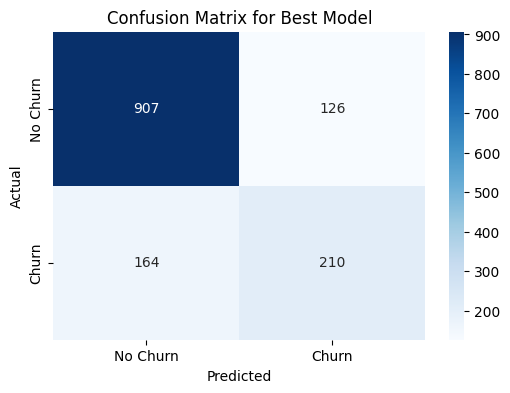

In [9]:
# Test accuracy
base_loss, base_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
tuned_loss, tuned_acc = tuned_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Baseline Test Accuracy: {base_acc:.4f}")
print(f"Tuned Test Accuracy: {tuned_acc:.4f}\n")

# Determine best model for detailed evaluation
best_model = tuned_model if tuned_acc >= base_acc else baseline_model
predictions = (best_model.predict(X_test_scaled) > 0.5).astype(int)

# Compare both models
print(f"Best Model Selected for Deep Evaluation: {'Tuned Model' if tuned_acc >= base_acc else 'Baseline Model'}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=['No Churn (0)', 'Churn (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Best Model')
plt.show()

## Save & Predict

In [10]:
# Save best model as .keras
best_model.save('Assignment3_Model.keras')
print("Model saved successfully as 'Assignment3_Model.keras'")

def predict_churn(customer_data_scaled):
    # Load saved model
    loaded_model = load_model('Assignment3_Model.keras')

    # Predict on a new hypothetical customer
    prediction_prob = loaded_model.predict(customer_data_scaled, verbose=0)[0][0]
    churn_status = "Will Churn" if prediction_prob > 0.5 else "Will Not Churn"

    print(f"\nHypothetical Customer Prediction: {churn_status}")
    print(f"Probability of Churn: {prediction_prob:.2%}")

# Creating a mock customer profile using the first row of our scaled test data
mock_customer = X_test_scaled[0].reshape(1, -1)
predict_churn(mock_customer)

Model saved successfully as 'Assignment3_Model.keras'

Hypothetical Customer Prediction: Will Not Churn
Probability of Churn: 2.22%


## Short Answer

*   **CNN vs Dense Network:** Convolutional Neural Networks (CNNs) are best utilized when the data has an underlying spatial or grid-like structure where local spatial relationships matter. Dense networks process all inputs globally and ignore spatial hierarchies. **Example Use Case:** Diagnosing diseases from medical X-ray imaging.
*   **RNN vs Dense Network:** Recurrent Neural Networks (RNNs) are designed for sequential data where the order of inputs and temporal context are crucial, allowing the network to maintain a "memory" of previous inputs. Dense networks treat every input independently without any concept of time or sequence. **Example Use Case:** Translating languages or predicting the next word in a sentence (Natural Language Processing).

## Reflection

*   **What I learned:** I learned how to build a complete end-to-end Keras pipeline, moving beyond standard machine learning classifiers into deep learning. Understanding how to handle imbalanced data metrics and implement tuning techniques like Batch Normalization and Dropout was particularly insightful.
*   **Challenges faced:** Ensuring that the categorical data was properly encoded so the neural network could interpret it computationally was challenging. Additionally, finding the right balance of patience in the Early Stopping callback to avoid stopping training prematurely required careful observation of the loss curves.
*   **Future improvements:** Moving forward, I would like to explore hyperparameter tuning libraries (like KerasTuner) to systematically find the optimal number of hidden units and learning rates. I also want to investigate techniques like SMOTE to artificially balance the dataset before training to improve recall on the minority class.